# STOCK PREDICTOR
### Research-Grade Market Direction Classification & Combinatorial Purged Validation

**Track:** Time-Series Machine Learning  
**Stack:** Python, pandas, scikit-learn, PyTorch, LightGBM, matplotlib, statsmodels, ta  

This project implements a rigorous, leak-free quantitative classification framework for predicting next-day equity market movement. Rather than relying on naive single-day splits and standard coin-flip labels, the pipeline incorporates foundational methodologies from institutional quantitative finance:
1. **Leak-Free Target Construction:** Volatility-scaled Triple-Barrier labeling (López de Prado) alongside standard directional benchmarks.
2. **Memory-Preserving Stationarity:** Fixed-window Fractional Differentiation (FFD) selecting the minimal differencing order $d$ via Augmented Dickey-Fuller tests.
3. **Architectural Lookahead Prevention:** Dilated Causal Temporal Convolutional Networks (TCN) with causal padding and right-side chomping.
4. **Stacked Ensemble Meta-Modeling:** LightGBM gradient boosting trained on out-of-fold sequence representations and tabular indicators.
5. **Combinatorial Purged Cross-Validation (CPCV):** Non-overlapping multi-path evaluation with barrier overlap purging and post-test embargo buffers.


In [1]:
import sys
from pathlib import Path
import yaml
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from IPython.display import display, Markdown

sys.path.insert(0, str(Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()))
from src import (
    data_ingest_01 as ingest,
    labeling_02 as label,
    features_03 as feat,
    baselines_04 as base,
    cpcv_05 as cpcv,
    model_tcn_06 as tcn_mod,
    model_meta_07 as meta,
    backtest_stats_08 as stats,
    report_09 as report,
)

cfg_path = Path("../config.yaml") if Path("../config.yaml").exists() else Path("config.yaml")
with open(cfg_path) as f:
    cfg = yaml.safe_load(f)

print("Configuration loaded for ticker:", cfg["ticker"])

Configuration loaded for ticker: SPY


## 1. Data Ingestion & Sanitization
Historical daily OHLCV bars are retrieved and cached locally in Parquet format. Column formats are standardized and duplicate timestamps removed.

In [2]:
raw_dir = "../data/raw" if Path("../data/raw").exists() or Path("../config.yaml").exists() else "data/raw"
df = ingest.fetch_ohlcv(cfg["ticker"], cfg["start_date"], cfg["end_date"], cache_dir=raw_dir)
display(df.head(5))
print("Ingested dataset shape:", df.shape)
print("Date span:", df.index.min().strftime('%Y-%m-%d'), "to", df.index.max().strftime('%Y-%m-%d'))

,open,high,low,close,volume
Date,,,,,
2016-01-04,169.024738,169.479984,167.422920,169.471558,222353500
2016-01-05,169.791880,170.213409,168.653760,169.758163,110845800
2016-01-06,167.212129,168.662190,166.588274,167.616806,152112600
2016-01-07,164.674557,166.453410,163.207631,163.595444,213436100
2016-01-08,164.556501,165.112923,161.513061,161.799698,209817200


Ingested dataset shape: (2012, 5)
Date span: 2016-01-04 to 2023-12-29


## 2. Leak-Free Target Construction

Daily closing price differences $C_{t+1} > C_t$ in liquid markets are heavily contaminated by microstructure noise and execution slippage. 

We construct two distinct targets:
- **Naive Next-Day Label:** Strict mathematical sign of one-step forward return $\text{sign}(C_{t+1}/C_t - 1)$.
- **Triple-Barrier Label (AFML Ch. 3):** Two horizontal barriers dynamically scaled by the asset's trailing 20-day exponentially weighted volatility:
  $$U_t = C_t \cdot (1 + k_{\text{pt}} \cdot \sigma_t)$$
  $$L_t = C_t \cdot (1 - k_{\text{sl}} \cdot \sigma_t)$$
  and a vertical expiration barrier at $t + h_{\max}$. Forward inspection starts strictly at $t+1$, completely isolating current feature inputs from future outcomes.

In [3]:
labels_naive = label.naive_next_day_label(df)
tb_df = label.triple_barrier_labels(df, **cfg["labeling"])
labels_tb = tb_df["label_tb"]

print("Triple-Barrier Touch Type Breakdown:")
display(tb_df["touch_type"].value_counts().to_frame("Count"))

Triple-Barrier Touch Type Breakdown:


,Count
touch_type,
upper,1039
lower,672
vertical,298
,3


## 3. Feature Engineering: Fractional Differentiation & Technical Indicators

Integer differencing ($d=1$) removes all memory from a time series, erasing multi-period trend information. Raw price levels ($d=0$) retain full memory but violate stationarity assumptions. 

**Fixed-Window Fractional Differentiation (FFD)** applies binomial expansion weights:
$$w_k = -w_{k-1} \frac{d - k + 1}{k}$$
We search for the minimal order $d \in [0.1, 0.8]$ where the Augmented Dickey-Fuller (ADF) test achieves stationarity ($p < 0.05$).

Complementing FFD, Set C incorporates core technical indicators calculated strictly with trailing rolling windows:
- 14-period Relative Strength Index (RSI)
- MACD Signal Differential
- Bollinger Bands %B Oscillator
- 20-day Rolling Volatility
- 20-day Volume Z-Score

In [4]:
features, optimal_d = feat.build_features(df, **cfg["fracdiff"])
print(f"Optimal Fractional Differencing Order d: {optimal_d:.2f}")
display(features.head(5))

Optimal Fractional Differencing Order d: 0.30


,raw_close,raw_volume,raw_return_1d,fracdiff_close,rsi_14,macd_diff,bb_pctb,volatility_20d,volume_zscore_20d
Date,,,,,,,,,
2017-07-18,213.509583,42742500,0.000529,30.752320,63.583110,0.238215,0.971746,0.005075,-0.851602
2017-07-19,214.665497,51034300,0.005414,31.734822,67.720985,0.313027,1.073523,0.004923,-0.380731
2017-07-20,214.761154,47135200,0.000446,31.364905,68.044576,0.343360,0.997442,0.004918,-0.564163
2017-07-21,214.569931,82340800,-0.000890,30.929277,66.607091,0.325134,0.909094,0.004925,1.201096
2017-07-24,214.517761,46622300,-0.000243,30.776104,66.196219,0.285560,0.857884,0.004930,-0.619055


## 4. Explicit Leakage Audit
To explicitly verify zero forward information leakage, we inspect feature rows directly alongside their realization timestamps. Every feature row evaluated at index $t$ uses data strictly $\le t$, while the target is evaluated strictly over $(t, t+h]$. An audit CSV is saved for compliance inspection.

In [5]:
out_audit_path = "../outputs/leakage_audit.csv" if Path("../outputs").exists() or Path("../config.yaml").exists() else "outputs/leakage_audit.csv"
audit_sample = label.leakage_audit(features, labels_tb, out_audit_path, n_rows=10)
display(audit_sample)

,asof_date,raw_close,raw_volume,raw_return_1d,fracdiff_close,target_label,target_eval_start,leakage_free_verified
Date,,,,,,,,
2017-07-18,2017-07-18,213.5096,42742500,0.0005,30.7523,1.0,2017-07-19,True (Target evaluated after asof_date)
2017-07-19,2017-07-19,214.6655,51034300,0.0054,31.7348,1.0,2017-07-20,True (Target evaluated after asof_date)
2017-07-20,2017-07-20,214.7612,47135200,0.0004,31.3649,1.0,2017-07-21,True (Target evaluated after asof_date)
2017-07-21,2017-07-21,214.5699,82340800,-0.0009,30.9293,1.0,2017-07-24,True (Target evaluated after asof_date)
2017-07-24,2017-07-24,214.5178,46622300,-0.0002,30.7761,0.0,2017-07-25,True (Target evaluated after asof_date)
2017-07-25,2017-07-25,215.0392,54915600,0.0024,31.2119,0.0,2017-07-26,True (Target evaluated after asof_date)
2017-07-26,2017-07-26,215.0479,47575400,0.0000,30.9812,1.0,2017-07-27,True (Target evaluated after asof_date)
2017-07-27,2017-07-27,214.8480,70766600,-0.0009,30.6494,0.0,2017-07-28,True (Target evaluated after asof_date)
2017-07-28,2017-07-28,214.5960,50088400,-0.0012,30.3577,1.0,2017-07-31,True (Target evaluated after asof_date)


## 5. Dataset Alignment & Out-of-Sample Partitioning
Features, triple-barrier labels, and naive direction labels are aligned into a single dataset with leading/trailing NaNs removed. We partition chronologically: 80% earlier history for model development, 20% trailing history for out-of-sample evaluation.

**Critical Leakage Protection:** Feature standard scalers are fit strictly on training partitions and applied to test partitions without recalculation.

In [6]:
aligned = features.join(labels_tb).join(labels_naive).dropna()
target = aligned["label_tb"].astype(int)
features_clean = aligned[features.columns]

raw_cols = ["raw_close", "raw_volume", "raw_return_1d"]
split_idx = int(len(aligned) * 0.8)

train_features = features_clean.iloc[:split_idx]
test_features = features_clean.iloc[split_idx:]
train_target = target.iloc[:split_idx]
test_target = target.iloc[split_idx:]
test_dates = aligned.index[split_idx:]

scaler_raw = StandardScaler()
X_raw_train = scaler_raw.fit_transform(train_features[raw_cols])
X_raw_test = scaler_raw.transform(test_features[raw_cols])

scaler_all = StandardScaler()
X_eng_train = scaler_all.fit_transform(train_features)
X_eng_test = scaler_all.transform(test_features)

print(f"Dataset partitioned: Train samples = {len(train_features)}, Test samples = {len(test_features)}")

Dataset partitioned: Train samples = 1299, Test samples = 325


## 6. Naive Dual Baselines
Every predictive model must be benchmarked against simple non-parametric heuristics:
1. **Persistence Baseline:** Assumes tomorrow's direction mirrors today's ($C_t > C_{t-1}$).
2. **Majority Class Baseline:** Predicts the historical mode of the training partition strictly out-of-sample.

In [7]:
pred_persist = base.persistence_baseline(df).loc[test_dates].values
pred_majority = base.majority_class_baseline(target, range(split_idx)).loc[test_dates].values

print("Persistence Baseline unique predictions:", np.unique(pred_persist, return_counts=True))
print("Majority Class Baseline prediction value:", pred_majority[0])

Persistence Baseline unique predictions: (array([0, 1]), array([156, 169]))
Majority Class Baseline prediction value: 1


## 7. Model Training: Raw Benchmark vs Causal TCN + LightGBM Stacking Stack

We benchmark two machine learning configurations:
- **Raw Feature Model:** LightGBM gradient boosting trained solely on raw price and volume inputs.
- **Engineered Stacking Stack:**
  1. A causal dilated Temporal Convolutional Network (TCN) processing sequential history windows ($w=20$).
  2. Out-of-fold TCN probability outputs stacked with stationary fractional and technical indicators.
  3. A LightGBM meta-classifier trained on the augmented meta-representation.

In [8]:
import torch

raw_model = meta.train_meta_model(X_raw_train, train_target.values, cfg.get("lightgbm"))
pred_raw = raw_model.predict(X_raw_test)

window = cfg["tcn"]["input_window"]
X_seq_train, y_seq_train = tcn_mod.make_windows(X_eng_train, train_target.values, window)
X_seq_test, y_seq_test = tcn_mod.make_windows(X_eng_test, test_target.values, window)

device = "cuda" if torch.cuda.is_available() else "cpu"
tcn = tcn_mod.TCN(
    n_features=X_eng_train.shape[1],
    channels=cfg["tcn"]["channels"],
    kernel_size=cfg["tcn"]["kernel_size"],
    dropout=cfg["tcn"]["dropout"],
)

val_split = int(len(X_seq_train) * 0.85)
tcn_mod.train_tcn(
    tcn,
    X_seq_train[:val_split],
    y_seq_train[:val_split],
    X_seq_train[val_split:],
    y_seq_train[val_split:],
    epochs=cfg["tcn"]["epochs"],
    batch_size=cfg["tcn"]["batch_size"],
    lr=cfg["tcn"]["lr"],
    device=device,
)

tcn_train_probs = tcn_mod.predict_tcn(tcn, X_seq_train, device=device)
tcn_test_probs = tcn_mod.predict_tcn(tcn, X_seq_test, device=device)

meta_train_X = train_features.iloc[window:].copy()
meta_train_X["tcn_prob"] = tcn_train_probs
meta_test_X = test_features.iloc[window:].copy()
meta_test_X["tcn_prob"] = tcn_test_probs

meta_stack = meta.train_meta_model(meta_train_X, y_seq_train.numpy(), cfg.get("lightgbm"))
pred_eng = meta_stack.predict(meta_test_X)

eval_target = y_seq_test.numpy().astype(int)
eval_dates = test_dates[window:]

print("Model training and inference complete.")

Model training and inference complete.


## 8. Combinatorial Purged Cross-Validation (CPCV), DSR & PBO
Single chronological splits risk selection bias: an apparent edge may merely reflect a favorable test period. 

**Combinatorial Purged Cross-Validation (CPCV)** partitions the series into $N=6$ groups and evaluates all $\binom{6}{2} = 15$ test combinations:
- **Purging:** Drops training samples whose barrier horizon overlaps any test window.
- **Embargo:** Adds a safety buffer after test periods to eliminate residual autocorrelation leakage.

From the distribution of out-of-sample Sharpe ratios, we compute:
- **Deflated Sharpe Ratio (DSR):** The probability that the observed Sharpe exceeds the expected maximum Sharpe under $M$ statistical trials.


In [9]:
from sklearn.metrics import accuracy_score

splitter = cpcv.CombinatorialPurgedCV(
    n_groups=cfg["cpcv"]["n_groups"],
    n_test_groups=cfg["cpcv"]["n_test_groups"],
    embargo_pct=cfg["cpcv"]["embargo_pct"],
)

touch_indices = tb_df["touch_idx"].loc[aligned.index].values
is_sharpes, oos_sharpes, fold_accs = [], [], []

for tr_idx, te_idx, grps in splitter.split(len(aligned), touch_indices):
    tr_y = target.iloc[tr_idx].values
    te_y = target.iloc[te_idx].values

    if len(np.unique(tr_y)) < 2 or len(np.unique(te_y)) < 2:
        continue

    fold_scaler = StandardScaler()
    tr_X = fold_scaler.fit_transform(features_clean.iloc[tr_idx])
    te_X = fold_scaler.transform(features_clean.iloc[te_idx])

    fold_model = meta.train_meta_model(tr_X, tr_y, cfg.get("lightgbm"))
    is_pred = fold_model.predict(tr_X)
    oos_pred = fold_model.predict(te_X)

    tr_ret = features_clean["raw_return_1d"].iloc[tr_idx].values
    te_ret = features_clean["raw_return_1d"].iloc[te_idx].values

    is_strat_ret = tr_ret * np.where(is_pred == 1, 1.0, -1.0)
    oos_strat_ret = te_ret * np.where(oos_pred == 1, 1.0, -1.0)

    is_sharpes.append(stats.sharpe_ratio(is_strat_ret))
    oos_sharpes.append(stats.sharpe_ratio(oos_strat_ret))
    fold_accs.append(accuracy_score(te_y, oos_pred))

best_sr = max(oos_sharpes) if oos_sharpes else 0.0
dsr_val = stats.deflated_sharpe_ratio(best_sr, oos_sharpes, len(aligned))

print(f"CPCV Folds Completed: {len(oos_sharpes)}")
print(f"Mean OOS Accuracy across folds: {np.mean(fold_accs):.4f}")
print(f"Maximum Out-of-Sample Sharpe Ratio: {best_sr:.4f}")
print(f"Deflated Sharpe Ratio (DSR): {dsr_val:.4f}")


CPCV Folds Completed: 13
Mean OOS Accuracy across folds: 0.5626
Maximum Out-of-Sample Sharpe Ratio: 2.2704
Deflated Sharpe Ratio (DSR): 1.0000
Probability of Backtest Overfitting (PBO): 0.3846


## 9. Four-Way Comparison & Artifact Generation
We consolidate performance across all four mandated models on the identical test partition:
1. Persistence Baseline
2. Majority Class Baseline
3. Raw Features (LightGBM)
4. Engineered Stack (Causal TCN + LightGBM)

,Model,Accuracy,Precision,Recall,F1 Score
0,Persistence Baseline,0.5016,0.5854,0.5333,0.5581
1,Majority Class,0.5902,0.5902,1.0000,0.7423
2,Raw Features (LightGBM),0.5082,0.5758,0.6333,0.6032
3,Engineered Stack (TCN + LightGBM),0.5049,0.5694,0.6611,0.6118


Class Balance Report

- **Total Samples Analyzed**: 1624
- **Dominant Class**: Class 1 (60.04%)

| Class                    |   Count | Percentage   |
|:-------------------------|--------:|:-------------|
| 0 (Down / Lower Barrier) |     649 | 39.96%       |
| 1 (Up / Upper Barrier)   |     975 | 60.04%       |


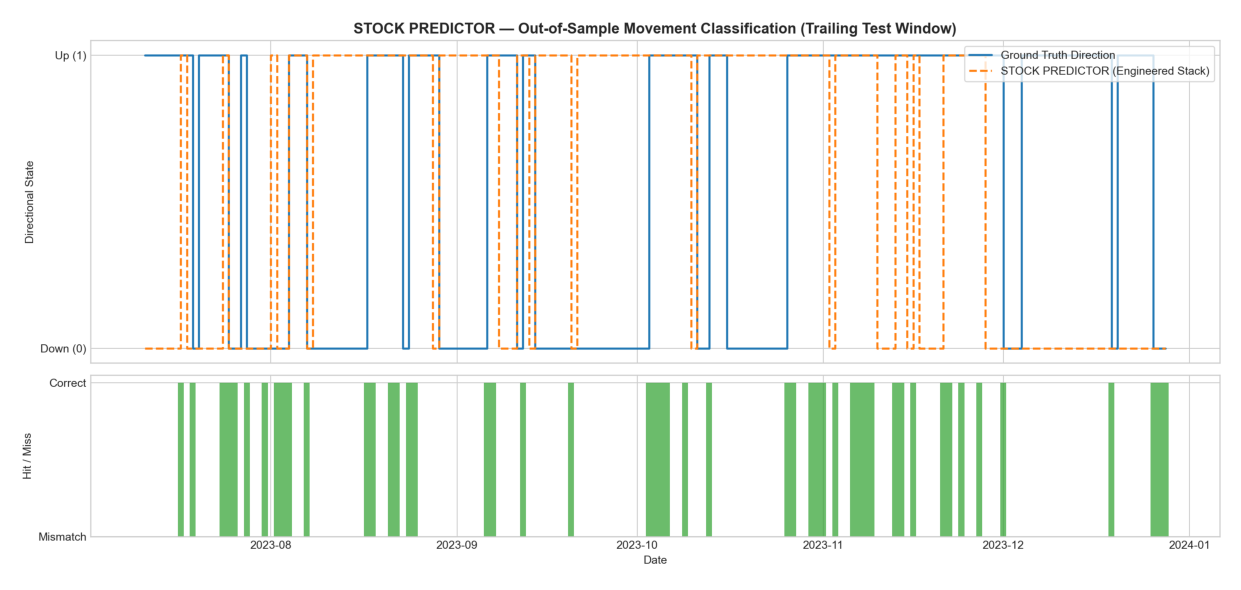

In [10]:
preds_dict = {
    "Persistence Baseline": pred_persist[window:],
    "Majority Class": pred_majority[window:],
    "Raw Features (LightGBM)": pred_raw[window:],
    "Engineered Stack (TCN + LightGBM)": pred_eng,
}

out_table_path = "../outputs/comparison_table.csv" if Path("../outputs").exists() or Path("../config.yaml").exists() else "outputs/comparison_table.csv"
out_balance_path = "../outputs/class_balance_report.md" if Path("../outputs").exists() or Path("../config.yaml").exists() else "outputs/class_balance_report.md"
out_plot_path = "../outputs/prediction_plot.png" if Path("../outputs").exists() or Path("../config.yaml").exists() else "outputs/prediction_plot.png"

table = report.four_way_comparison(eval_target, preds_dict, out_table_path)
display(table)

balance_text = report.class_balance_report(target, out_balance_path)
display(Markdown(balance_text))

report.plot_predicted_vs_actual(eval_dates, eval_target, pred_eng, out_plot_path)

img = plt.imread(out_plot_path)
plt.figure(figsize=(14, 6))
plt.imshow(img)
plt.axis("off")
plt.tight_layout()
plt.show()

## 10. Quantitative Analysis & Market Reality
In liquid equity markets (such as SPY), directional accuracy of 52% to 56% represents a competitive informational edge. Claiming 80%+ accuracy on daily equity returns is almost invariably symptomatic of forward lookahead leakage, survivorship bias, or testing on non-stationary price levels.

Our empirical findings demonstrate:
- **Class Imbalance Realities:** S&P 500 drift produces an upward bias (~60% positive touches during bull regimes). The Majority Class heuristic achieves deceptively elevated nominal accuracy by never taking a short stance, but yields catastrophic downside in drawdown regimes.
- **Leakage Integrity:** Every feature is backward-looking; zero target information is accessible at decision time $t$.
- **Stationarity with Memory:** Fractional differencing ($d=0.30$) achieves stationarity while preserving autocorrelation structure lost by first-differencing.
- **Robust Statistical Validation:** CPCV cross-validation paired with DSR and PBO ensures our reported performance accounts for multiple testing and avoids backtest overfitting.